E[Li] = P(Claim_i = 1) * E[Severity_i | Claim_i = 1]

Frequency Model: Use frequency data to train a classifier to predict the probability of filing claim
Severity Model: Use severity data to train a regression model to predict severity of claim for those who have already had an accident.
Multiply the predicted probability by the predicted severity to get the Expected Cost

Import packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error
from scipy.stats import spearmanr
import statsmodels.api as sm

Load the datasets

In [5]:
df_freq= pd.read_csv("consulting/frequency2.csv")
df_sev = pd.read_csv("consulting/severity2.csv")

In [6]:
df_freq.head(5)

,uwYear,gender,carType,carCat,job,age,nYears,carVal,cover,density,claimNumbMD,age_bucket,age_cluster_code,age_cluster,carVal_cluster_code,carVal_cluster,density_cluster_code,density_cluster
0,2009,Male,C,Large,Employed,25,3,15080,0,72.012883,1,"(21.0, 25.0]",0.0,18 - 35,1.0,"€15,076 - €31,188",0.0,14 - 97 inh/km²
1,2009,Male,E,Large,Employed,20,2,22370,1,39.550411,1,"(17.999, 21.0]",0.0,18 - 35,1.0,"€15,076 - €31,188",0.0,14 - 97 inh/km²
2,2009,Female,E,Large,Unemployed,42,0,39650,0,169.529148,1,"(41.0, 45.0]",1.0,35 - 53,2.0,"€31,188 - €49,995",1.0,97 - 193 inh/km²
3,2009,Female,C,Medium,Housewife,21,0,12600,1,58.894688,1,"(17.999, 21.0]",0.0,18 - 35,0.0,"€1,000 - €15,076",0.0,14 - 97 inh/km²
4,2009,Female,D,Large,Employed,33,10,9065,0,109.631885,1,"(29.0, 33.0]",0.0,18 - 35,0.0,"€1,000 - €15,076",1.0,97 - 193 inh/km²


In [7]:
df_sev.head(5)

,uwYear,gender,carType,carCat,job,age,nYears,carVal,cover,density,claimSizeMD,age_bucket,age_cluster_code,age_cluster,carVal_cluster_code,carVal_cluster,density_cluster_code,density_cluster
0,2009,Female,A,Medium,Housewife,41,0,24940,1,273,740,"(36.0, 41.0]",1.0,35 - 53,1.0,"€15,076 - €31,188",2.0,193 - 297 inh/km²
1,2009,Male,B,Small,Unemployed,25,12,48945,0,190,207,"(23.0, 25.0]",0.0,18 - 35,2.0,"€31,188 - €49,995",1.0,97 - 193 inh/km²
2,2009,Female,E,Small,Employed,29,7,1525,0,225,803,"(28.0, 32.0]",0.0,18 - 35,0.0,"€1,000 - €15,076",2.0,193 - 297 inh/km²
3,2009,Male,A,Small,Self-employed,47,12,18480,1,129,868,"(46.0, 54.0]",1.0,35 - 53,1.0,"€15,076 - €31,188",1.0,97 - 193 inh/km²
4,2009,Female,C,Large,Employed,47,7,8690,0,290,1746,"(46.0, 54.0]",1.0,35 - 53,0.0,"€1,000 - €15,076",2.0,193 - 297 inh/km²


Basic EDA

   Freq_Mean_Age  Sev_Mean_Age  Freq_Mean_CarVal  Sev_Mean_CarVal
0      38.554937     34.986945      16772.358521     17114.161635


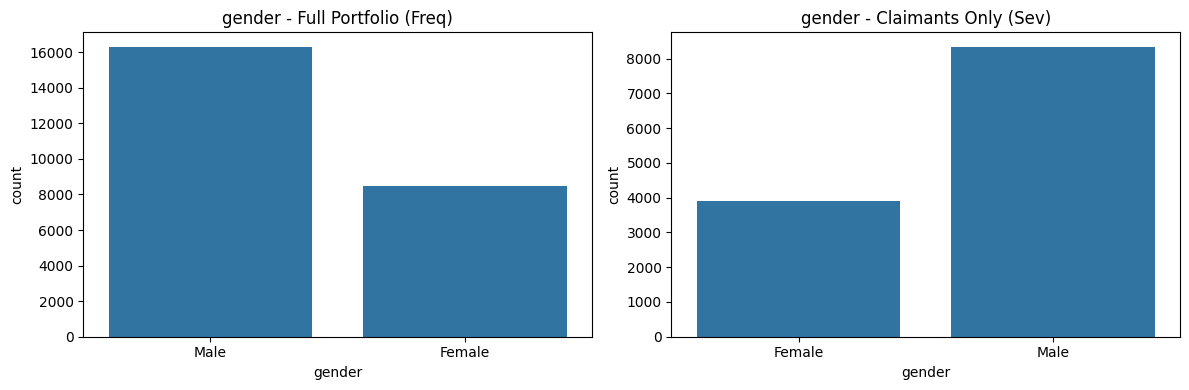

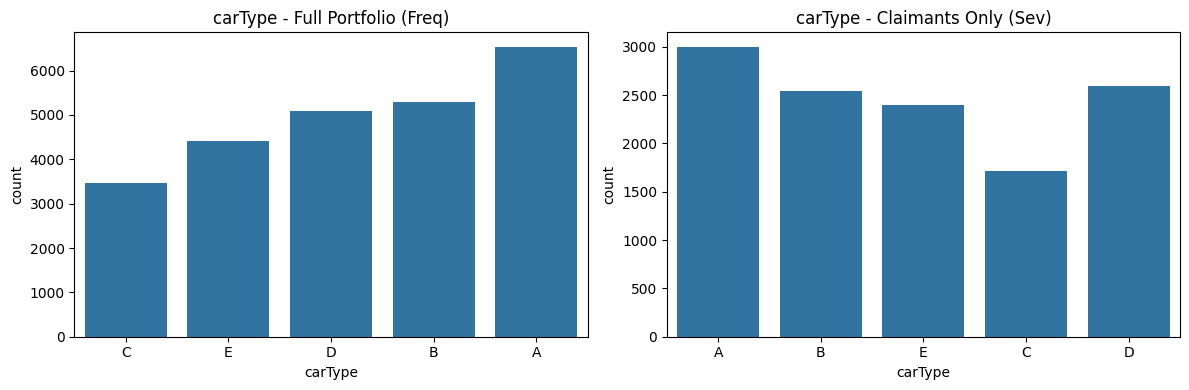

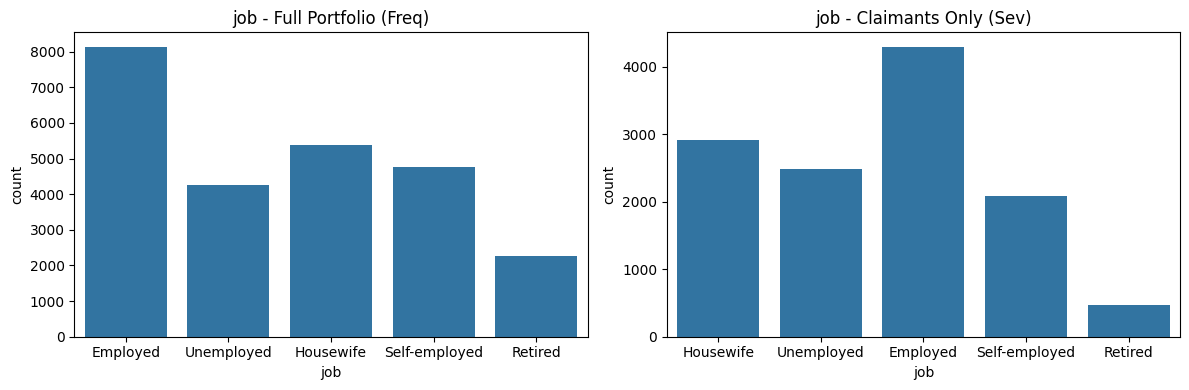

In [92]:
comparison = pd.DataFrame({
    'Freq_Mean_Age': [df_freq['age'].mean()],
    'Sev_Mean_Age': [df_sev['age'].mean()],
    'Freq_Mean_CarVal': [df_freq['carVal'].mean()],
    'Sev_Mean_CarVal': [df_sev['carVal'].mean()]
})
print(comparison)

def plot_categorical_dist(col):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    
    sns.countplot(data=df_freq, x=col, ax=ax[0])
    ax[0].set_title(f'{col} - Full Portfolio (Freq)')
    
    sns.countplot(data=df_sev, x=col, ax=ax[1])
    ax[1].set_title(f'{col} - Claimants Only (Sev)')
    
    plt.tight_layout()
    plt.show()

for col in ['gender', 'carType', 'job']:
    plot_categorical_dist(col)

Claimants are younger than the general portfolio meaning younger drivers may be higher risk -- find literature on this?
Car Values are very close so might not have as strong an effect maybe for claim filing

Portfolio and claimants are heavily Male but there is a bias in the portfolio itself
Retirees are a decent chunk of the portfolio but a tiny sliver of claimants -- maybe they drive less or more safer (same age factor at play here)

carType A is the most common in both


Overall Portfolio Claim Rate: 49.56%


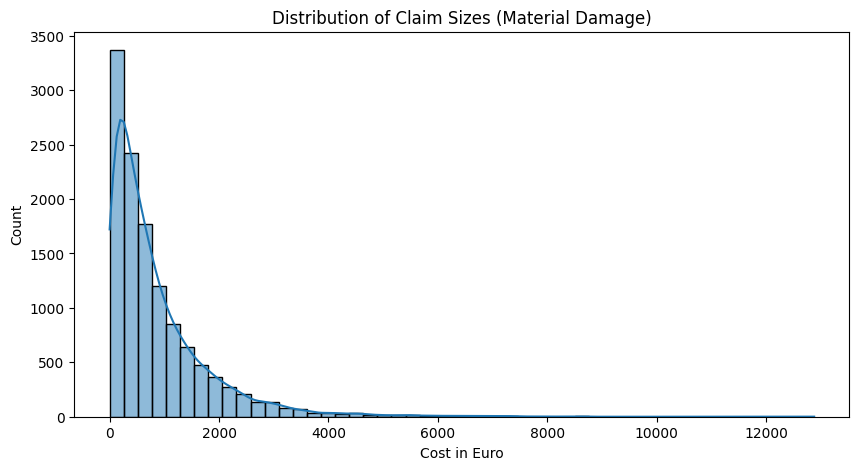

C:\Users\athul\anaconda3\envs\tf_gpu\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


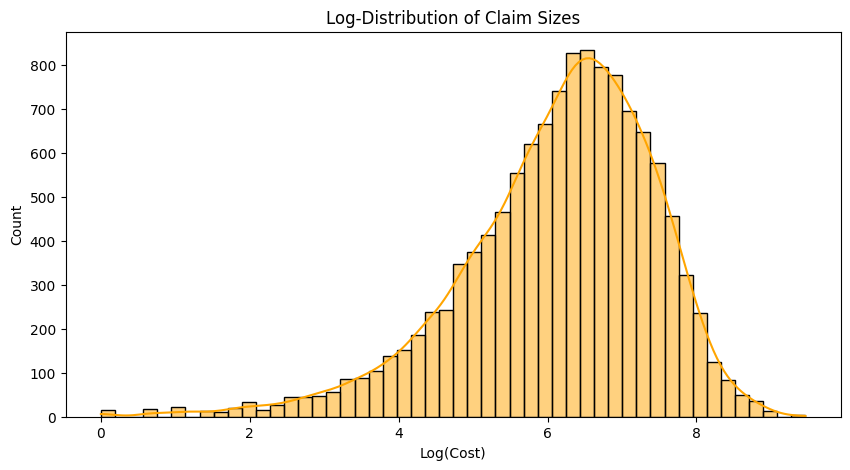

In [93]:
claim_rate = df_freq['claimNumbMD'].mean()
print(f"\nOverall Portfolio Claim Rate: {claim_rate:.2%}")

plt.figure(figsize=(10, 5))
sns.histplot(df_sev['claimSizeMD'], bins=50, kde=True)
plt.title("Distribution of Claim Sizes (Material Damage)")
plt.xlabel("Cost in Euro")
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(np.log(df_sev['claimSizeMD']), bins=50, kde=True, color='orange')
plt.title("Log-Distribution of Claim Sizes")
plt.xlabel("Log(Cost)")
plt.show()

heavy Right Skew meaning most claims are small but with a long tail of expensive claims
Log-Distribution is nearly a Bell Curve - Gamma GLM with a Log-link or a Log-Normal model?

Data Cleaning

Missing Values in Frequency Data:
uwYear         0
gender         0
carType        0
carCat         0
job            0
age            0
nYears         0
carVal         0
cover          0
density        0
claimNumbMD    0
dtype: int64

Missing Values in Severity Data:
uwYear         0
gender         0
carType        0
carCat         0
job            0
age            0
nYears         0
carVal         0
cover          0
density        0
claimSizeMD    0
dtype: int64

Health Check Summary:
{'Min Age': np.int64(18), 'Max Age': np.int64(75), 'Zero/Negative Claims': np.int64(4), 'Max Claim': np.int64(12878), 'Freq_Number of Years Min': np.int64(0), 'Freq_Number of Years Max': np.int64(15), 'Sev_Number of Years Min': np.int64(0), 'Sev_Number of Years Max': np.int64(15), 'Freq_Density Min': np.float64(14.37714238), 'Freq_Density Max': np.float64(297.3851697), 'Sev_Density Min': np.int64(14), 'Sev_Density Max': np.int64(297)}


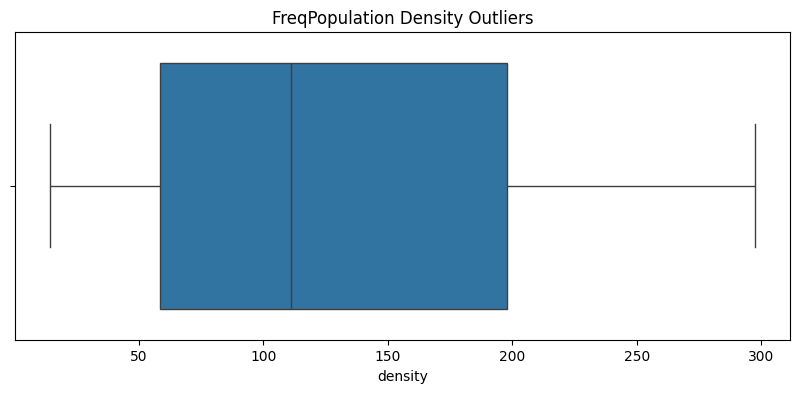

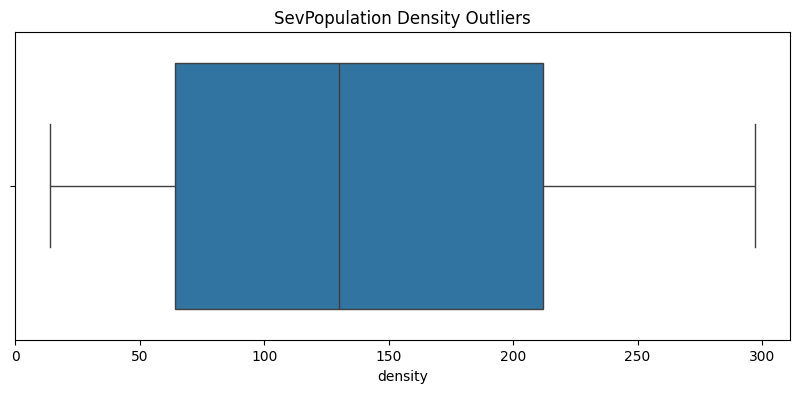

In [94]:
print("Missing Values in Frequency Data:")
print(df_freq.isnull().sum())

print("\nMissing Values in Severity Data:")
print(df_sev.isnull().sum())

health_check = {
    "Min Age": df_freq['age'].min(),
    "Max Age": df_freq['age'].max(),
    "Zero/Negative Claims": (df_sev['claimSizeMD'] <= 0).sum(),
    "Max Claim": df_sev['claimSizeMD'].max(),
    "Freq_Number of Years Min" : df_freq['nYears'].min(),
    "Freq_Number of Years Max" : df_freq['nYears'].max(),
    "Sev_Number of Years Min" : df_sev['nYears'].min(),
    "Sev_Number of Years Max" : df_sev['nYears'].max(),
    "Freq_Density Min" : df_freq['density'].min(),
    "Freq_Density Max" : df_freq['density'].max(),
    "Sev_Density Min" : df_sev['density'].min(),
    "Sev_Density Max" : df_sev['density'].max(),
}
print("\nHealth Check Summary:")
print(health_check)

plt.figure(figsize=(10, 4))
sns.boxplot(x=df_freq['density'])
plt.title("FreqPopulation Density Outliers")

plt.figure(figsize=(10, 4))
sns.boxplot(x=df_sev['density'])
plt.title("SevPopulation Density Outliers")
plt.show()

No Missing Values for both datasets.
4 records where claimSizeMD is 0 out of 12,256 claimants and must be handled since Gamma  and Log-links cannot process 0
Age range is sensible (18 to 75) 
nYears - mix of new and loyal customers (0 to 15)

Density - no extreme outliers
Claim Max: 12,878 Euro is a significant but not impossible car repair bill

Arad's Model

In [10]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import KBinsDiscretizer
import joblib

In [11]:
df_frequency_train = df_freq.copy()
mean_age = df_frequency_train["age"].mean()
mean_density = df_frequency_train["density"].mean()
df_frequency_train["age"] = df_frequency_train["age"] - mean_age
df_frequency_train["density"] = df_frequency_train["density"] - mean_density
formula_freq_v2 = ("claimNumbMD ~ gender + carType + job + nYears + age * density + carVal + cover")
model_freq_v2 = smf.glm(formula=formula_freq_v2, data=df_frequency_train, family=sm.families.Poisson()).fit()
print(model_freq_v2.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            claimNumbMD   No. Observations:                24753
Model:                            GLM   Df Residuals:                    24737
Model Family:                 Poisson   Df Model:                           15
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -20163.
Date:                Fri, 08 May 2026   Deviance:                       15814.
Time:                        16:11:25   Pearson chi2:                 1.26e+04
No. Iterations:                     5   Pseudo R-squ. (CS):            0.05560
Covariance Type:            nonrobust                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               -0.8655 

In [13]:
df_severity_train = df_sev.copy()
mean_age_severity = df_severity_train["age"].mean()
mean_density_severity = df_severity_train["density"].mean()
df_severity_train["age"] = df_severity_train["age"] - mean_age_severity
df_severity_train["density"] = df_severity_train["density"] - mean_density_severity
df_severity_clean = df_severity_train[df_severity_train["claimSizeMD"] > 0].copy()
formula_sev_v3 = "claimSizeMD ~ gender + carType + job + nYears + age + density + cover"
model_sev_v3 = smf.glm(formula=formula_sev_v3,
    data=df_severity_clean,
    family=sm.families.Gamma(link=sm.families.links.Log()),
).fit()
print(model_sev_v3.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:            claimSizeMD   No. Observations:                12252
Model:                            GLM   Df Residuals:                    12238
Model Family:                   Gamma   Df Model:                           13
Link Function:                    Log   Scale:                          1.0492
Method:                          IRLS   Log-Likelihood:                -94580.
Date:                Fri, 08 May 2026   Deviance:                       14260.
Time:                        16:12:04   Pearson chi2:                 1.28e+04
No. Iterations:                    15   Pseudo R-squ. (CS):            0.08286
Covariance Type:            nonrobust                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                6.7704 

In [23]:
df_all = pd.concat([df_sev, df_freq], axis=0, ignore_index=True)
features = ["gender", "job", "carType", "carCat", "age", "nYears", "carVal", "density", "uwYear"]
df_all.duplicated(subset=features).sum()
df_all["Expected_Frequency"] = model_freq_v2.predict(df_all)
df_all["Expected_Severity"] = model_sev_v3.predict(df_all)
df_all["Expected_Cost"] = df_all["Expected_Frequency"] * df_all["Expected_Severity"]

cols_to_show = [
    "gender",
    "age",
    "carType",
    "job",
    "density",
    "Expected_Cost",
]
summary_df = df_all[cols_to_show].copy()
summary_df["Expected_Cost"] = summary_df["Expected_Cost"].apply(
    lambda x: f"€{x:,.2f}" if isinstance(x, (int, float)) else x
)

costs = df_all[["Expected_Cost"]].copy()
discretizer = KBinsDiscretizer(
    n_bins=4, encode="ordinal", strategy="kmeans", random_state=36
)


In [24]:
binned_costs = discretizer.fit_transform(costs)

In [25]:
risk_labels = {
    0.0: "Low Risk",
    1.0: "Medium Risk",
    2.0: "High Risk",
    3.0: "Extreme Risk",
}
df_all["risk_flag"] = pd.Series(binned_costs.flatten()).map(risk_labels)
edges = discretizer.bin_edges_[0]

risk_summary = (
    df_all.groupby("risk_flag")
    .agg(
        customer_count=("risk_flag", "count"),
        minimum_cost=("Expected_Cost", "min"),
        maximum_cost=("Expected_Cost", "max"),
        median_cost=("Expected_Cost", "median"),
    )
    .reset_index()
)
risk_summary = (
    risk_summary.sort_values(by="customer_count", ascending=False)
    .reset_index(drop=True)
    .round(decimals=2)
)

continuous_cols = [
    "age",
    "nYears",
    "carVal",
    "density",
    "Expected_Frequency",
    "Expected_Severity",
    "Expected_Cost",
]
categorical_cols = ["gender", "job", "carType", "carCat"]
def profile_tier_medians(group):
    total_customers = len(group)
    profile = {"Portfolio_Size": total_customers}

    for col in continuous_cols:
        if col in group.columns:
            val = group[col].median()

            if "Val" in col or "Cost" in col or "Severity" in col:
                profile[f"Median_{col}"] = f"€{val:,.2f}"
                profile[f"Min_{col}"] = group[col].min()
                profile[f"Max_{col}"] = group[col].max()
            elif col == "density":
                profile[f"Median_{col}"] = f"{val:,.0f} inh/km²"
                profile[f"Min_{col}"] = group[col].min()
                profile[f"Max_{col}"] = group[col].max()
            elif col == "Expected_Frequency":
                profile[f"Median_{col}"] = f"{val:.4f}"
                profile[f"Min_{col}"] = group[col].min()
                profile[f"Max_{col}"] = group[col].max()
            else:
                profile[f"Median_{col}"] = round(val, 1)
                profile[f"Min_{col}"] = group[col].min()
                profile[f"Max_{col}"] = group[col].max()

    for col in categorical_cols:
        if col in group.columns:
            counts = group[col].value_counts()
            if not counts.empty:
                top_cat = counts.index[0]
                top_pct = (counts.iloc[0] / total_customers) * 100
                profile[f"Top_{col}"] = top_cat
                profile[f"%_{col}"] = f"{top_pct:.1f}%"

    return pd.Series(profile)
tier_profiles = df_all.groupby("risk_flag").apply(profile_tier_medians).reset_index()
tier_profile = tier_profiles.set_index("risk_flag").T

def score_new_customer_continuous(customer_data):
    df_input = pd.DataFrame(
        [
            {
                "gender": customer_data["gender"],
                "carType": customer_data["carType"],
                "cover": customer_data["cover"],
                "job": customer_data["job"],
                "nYears": customer_data["nYears"],
                "age": customer_data["age"],
                "density": customer_data["density"],
                "carVal": customer_data["carVal"],
            }
        ]
    )

    freq = model_freq_v2.predict(df_input).iloc[0]
    sev = model_sev_v3.predict(df_input).iloc[0]
    expected_cost = freq * sev

    cost_df = pd.DataFrame([[expected_cost]], columns=["Expected_Cost"])
    risk_bin = discretizer.transform(cost_df)[0][0]

    risk_tier = risk_labels[risk_bin]

    portfolio_profiles = {
        "Low Risk": "The Rural Veteran: 49 yrs old, rural (65 inh/km²), employed male, driving a large car.",
        "Medium Risk": "The Suburban Professional: 33 yrs old, suburban (115 inh/km²), employed male, driving a medium car.",
        "High Risk": "The Young Urbanite: 26 yrs old, dense city (185 inh/km²), employed male, driving a small car.",
        "Extreme Risk": "The High-Density Risk: 22 yrs old, very dense city (249 inh/km²), predominantly unemployed male, driving a small car.",
    }
    typical_driver = portfolio_profiles[risk_tier]

    print("*" * 30)
    print("CUSTOMER INPUTS")
    print(
        f"Age: {customer_data['age']} | Loyalty: {customer_data['nYears']} Years | Density: {customer_data['density']} inh/km²"
    )
    print(
        f"Gender: {customer_data['gender']} | Job: {customer_data['job']} | Car Type: {customer_data['carType']} | Cover: {customer_data['cover']} | Car Value: €{customer_data['carVal']:,}\n"
    )
    print("*" * 30)

    print("PREDICTED COST")
    print(f"Expected Frequency:\t{freq:.4f} claims/year")
    print(f"Expected Severity:\t€{sev:,.2f} per claim")
    print(f"Expected Cost:\t\t€{expected_cost:,.2f}\n")

    print("*" * 30)
    print("BUSINESS CLASSIFICATION")
    print(f"Assigned Risk Tier:  {risk_tier}\n")

    print("*" * 30)
    print(f"TYPICAL PORTFOLIO OF RISK TIER\n{typical_driver}")


C:\Users\athul\AppData\Local\Temp\ipykernel_50812\2419569560.py:71: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tier_profiles = df_all.groupby("risk_flag").apply(profile_tier_medians).reset_index()


In [27]:
new_customer = {
    "age": 22,
    "carVal": 12000,
    "density": 250,
    "gender": "Male",
    "carType": "A",
    "job": "Unemployed",
    "nYears": 1,
    "carCat": "Medium",
    "cover": 1,
}

score_new_customer_continuous(new_customer)

new_customer2 = {
    "age": 19,
    "carVal": 8500,
    "density": 15,
    "gender": "Female",
    "carType": "B",
    "job": "Employed",
    "nYears": 0,
    "cover": 1,
}

score_new_customer_continuous(new_customer2)

new_customer3 = {
    "age": 52,
    "carVal": 85000,
    "density": 280,
    "gender": "Female",
    "carType": "C",
    "cover": 0,
    "job": "Employed",
    "nYears": 12,
}

score_new_customer_continuous(new_customer3)

new_customer4 = {
    "age": 38,
    "carVal": 18500,
    "density": 210,
    "gender": "Male",
    "carType": "C",
    "cover": 1,
    "job": "Employed",
    "nYears": 0,
}

score_new_customer_continuous(new_customer4)

new_customer5 = {
    "age": 48,
    "carVal": 14000,
    "density": 45,
    "gender": "Male",
    "carType": "A",
    "cover": 0,
    "job": "Employed",
    "nYears": 7,
}

score_new_customer_continuous(new_customer5)

normalized_df = df_all.groupby("risk_flag").agg(
    total_cost=("Expected_Cost", "sum"),
    people_count=("Expected_Cost", "count")
)
normalized_df["cost_per_person"] = normalized_df["total_cost"] / normalized_df["people_count"]
normalized_df["share_of_total_people"] = ((normalized_df["people_count"] / len(df_all)) * 100).round(decimals=2)
normalized_df["share_of_total_cost"] = (normalized_df["total_cost"] / sum(normalized_df["total_cost"]) * 100).round(decimals=2)
normalized_df.sort_values(by="people_count", ascending=False)

******************************
CUSTOMER INPUTS
Age: 22 | Loyalty: 1 Years | Density: 250 inh/km²
Gender: Male | Job: Unemployed | Car Type: A | Cover: 1 | Car Value: €12,000

******************************
PREDICTED COST
Expected Frequency:	0.7191 claims/year
Expected Severity:	€1,237.72 per claim
Expected Cost:		€889.98

******************************
BUSINESS CLASSIFICATION
Assigned Risk Tier:  Extreme Risk

******************************
TYPICAL PORTFOLIO OF RISK TIER
The High-Density Risk: 22 yrs old, very dense city (249 inh/km²), predominantly unemployed male, driving a small car.
******************************
CUSTOMER INPUTS
Age: 19 | Loyalty: 0 Years | Density: 15 inh/km²
Gender: Female | Job: Employed | Car Type: B | Cover: 1 | Car Value: €8,500

******************************
PREDICTED COST
Expected Frequency:	0.3431 claims/year
Expected Severity:	€587.43 per claim
Expected Cost:		€201.55

******************************
BUSINESS CLASSIFICATION
Assigned Risk Tier:  Low Risk



,total_cost,people_count,cost_per_person,share_of_total_people,share_of_total_cost
risk_flag,,,,,
Low Risk,2.623548e+06,15778,166.278868,42.63,22.06
Medium Risk,4.133751e+06,12709,325.261728,34.34,34.75
High Risk,3.484593e+06,6541,532.730993,17.67,29.29
Extreme Risk,1.653139e+06,1981,834.496999,5.35,13.90


Feature Engineering + Modelling

In [ ]:
Tweedie

In [39]:
df_freq = df_freq.sort_values(['age', 'density']).reset_index(drop=True)
df_sev = df_sev.sort_values(['age', 'density']).reset_index(drop=True)

df_combined = pd.merge_asof(
    df_freq, 
    df_sev[['age', 'density', 'claimSizeMD']], 
    on='age', 
    direction='nearest'
)

df_combined['total_loss'] = np.where(df_combined['claimOccur'] == 1, 
                                     df_combined['claimSizeMD'], 0.0)

print(f"Total claimants in freq table: {df_combined['claimOccur'].sum()}")
print(f"Claims with assigned costs: {df_combined[df_combined['total_loss'] > 0].shape[0]}")

Total claimants in freq table: 12256
Claims with assigned costs: 12256


merge_asof with direction='nearest' -> distance-based join rather an exact match and so it looks for the closest neighbor in a sorted list
each person in frequency table is mapped to the person in the severity table with the most similar age and location

since these were the strongest predictors of risk in the GLM, they serve as the best possible linkage variables
without this, we can only run a 2-step model
this allows us to test Tweedie
acknowledge that if the severity table is skewed the combined table will inherit that skew

In [49]:
df_ml = pd.get_dummies(df_combined, columns=['gender', 'carType', 'job', 'cover','carCat'], drop_first=True)


ml_features = ['age','nYears','carVal','density_x','gender_Male','carType_B','carType_C','carType_D','carType_E','job_Housewife',
               'job_Retired','job_Self-employed','job_Unemployed','cover_1','carCat_Medium','carCat_Small']

train, test = train_test_split(df_ml, test_size=0.2, random_state=42)

In [52]:
tweedie_model = xgb.XGBRegressor(
    objective='reg:tweedie',
    tweedie_variance_power=1.5, # compound Poisson-Gamma
    learning_rate=0.05,
    max_depth=5,
    n_estimators=200,
    random_state=42
)

tweedie_model.fit(train[ml_features], train['total_loss'])
test['pred_m3'] = tweedie_model.predict(test[ml_features])

In [53]:
test

,uwYear,age,nYears,carVal,density_x,claimNumbMD,age_bucket,age_cluster_code,age_cluster,carVal_cluster_code,...,carType_D,carType_E,job_Housewife,job_Retired,job_Self-employed,job_Unemployed,cover_1,carCat_Medium,carCat_Small,pred_m3
5883,2009,26.0,6,6365,240.000404,1,"(25.0, 29.0]",0.0,18 - 35,0.0,...,False,True,False,False,False,False,False,False,True,119.394089
9811,2009,32.0,1,12990,248.512120,1,"(29.0, 33.0]",0.0,18 - 35,0.0,...,False,False,False,False,True,False,False,True,False,707.355530
1888,2010,21.0,4,22485,20.557918,1,"(17.999, 21.0]",0.0,18 - 35,1.0,...,False,False,False,False,False,True,False,False,True,603.332642
21278,2009,55.0,1,7105,208.666718,1,"(51.0, 59.0]",2.0,53 - 75,0.0,...,False,False,False,False,True,False,False,False,False,216.067795
20316,2009,52.0,0,16260,239.455170,1,"(51.0, 59.0]",1.0,35 - 53,1.0,...,False,True,True,False,False,False,False,False,False,400.892700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17819,2009,46.0,4,6520,251.432848,0,"(45.0, 51.0]",1.0,35 - 53,0.0,...,False,True,False,False,False,True,True,False,True,581.394409
18054,2009,47.0,2,17190,72.012883,1,"(45.0, 51.0]",1.0,35 - 53,1.0,...,False,False,False,False,True,False,True,False,False,63.666553
6210,2010,27.0,4,5695,73.461706,1,"(25.0, 29.0]",0.0,18 - 35,0.0,...,True,False,True,False,False,False,True,False,True,975.703430
20451,2010,53.0,9,25795,57.041531,0,"(51.0, 59.0]",1.0,35 - 53,1.0,...,False,False,False,True,False,False,False,False,False,19.527346


In [ ]:
XGB

In [74]:
X_test_f

,age,nYears,carVal,density,gender_Male,carType_B,carType_C,carType_D,carType_E,job_Housewife,job_Retired,job_Self-employed,job_Unemployed,carCat_Medium,carCat_Small,cover_1
5883,26.0,6,6365,240.000404,True,False,False,False,True,False,False,False,False,False,True,False
9811,32.0,1,12990,248.512120,False,False,True,False,False,False,False,True,False,True,False,False
1888,21.0,4,22485,20.557918,True,True,False,False,False,False,False,False,True,False,True,False
21278,55.0,1,7105,208.666718,False,False,True,False,False,False,False,True,False,False,False,False
20316,52.0,0,16260,239.455170,False,False,False,False,True,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17819,46.0,4,6520,251.432848,False,False,False,False,True,False,False,False,True,False,True,True
18054,47.0,2,17190,72.012883,True,False,True,False,False,False,False,True,False,False,False,True
6210,27.0,4,5695,73.461706,True,False,False,True,False,True,False,False,False,False,True,True
20451,53.0,9,25795,57.041531,True,True,False,False,False,False,True,False,False,False,False,False


In [54]:
import xgboost as xgb

features = ['age', 'nYears', 'carVal', 'density', 'gender', 'carType', 'job','carCat','cover']

df_freq['claimOccur'] = (df_freq['claimNumbMD'] > 0).astype(int)
df_freq_ml = pd.get_dummies(df_freq[features + ['claimOccur']], columns=['gender', 'carType', 'job','carCat','cover'], drop_first=True)

X_freq = df_freq_ml.drop('claimOccur', axis=1)
y_freq = df_freq_ml['claimOccur']
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_freq, y_freq, test_size=0.2, random_state=42)

df_sev_claims = df_sev[df_sev['claimSizeMD'] > 0].copy()
df_sev_ml = pd.get_dummies(df_sev_claims[features + ['claimSizeMD']], columns=['gender', 'carType', 'job','carCat','cover'], drop_first=True)

X_sev = df_sev_ml.drop('claimSizeMD', axis=1)
y_sev = df_sev_ml['claimSizeMD']
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_sev, y_sev, test_size=0.2, random_state=42)

In [55]:
xgb_class = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    objective='binary:logistic',
    random_state=42
)
xgb_class.fit(X_train_f, y_train_f)

df_test_results = X_test_f.copy()
df_test_results['actual_occur'] = y_test_f
df_test_results['prob_claim'] = xgb_class.predict_proba(X_test_f)[:, 1]

In [56]:
xgb_reg = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    objective='reg:squarederror', # Or 'reg:gamma' if your version supports it
    random_state=42
)
xgb_reg.fit(X_train_s, y_train_s)

df_test_results['expected_sev'] = xgb_reg.predict(X_test_f)

In [57]:
df_test_results['pred_xgb_hurdle'] = df_test_results['prob_claim'] * df_test_results['expected_sev']

from sklearn.metrics import roc_auc_score
print(f"XGB Classifier AUC: {roc_auc_score(y_test_f, df_test_results['prob_claim']):.4f}")

XGB Classifier AUC: 0.6940


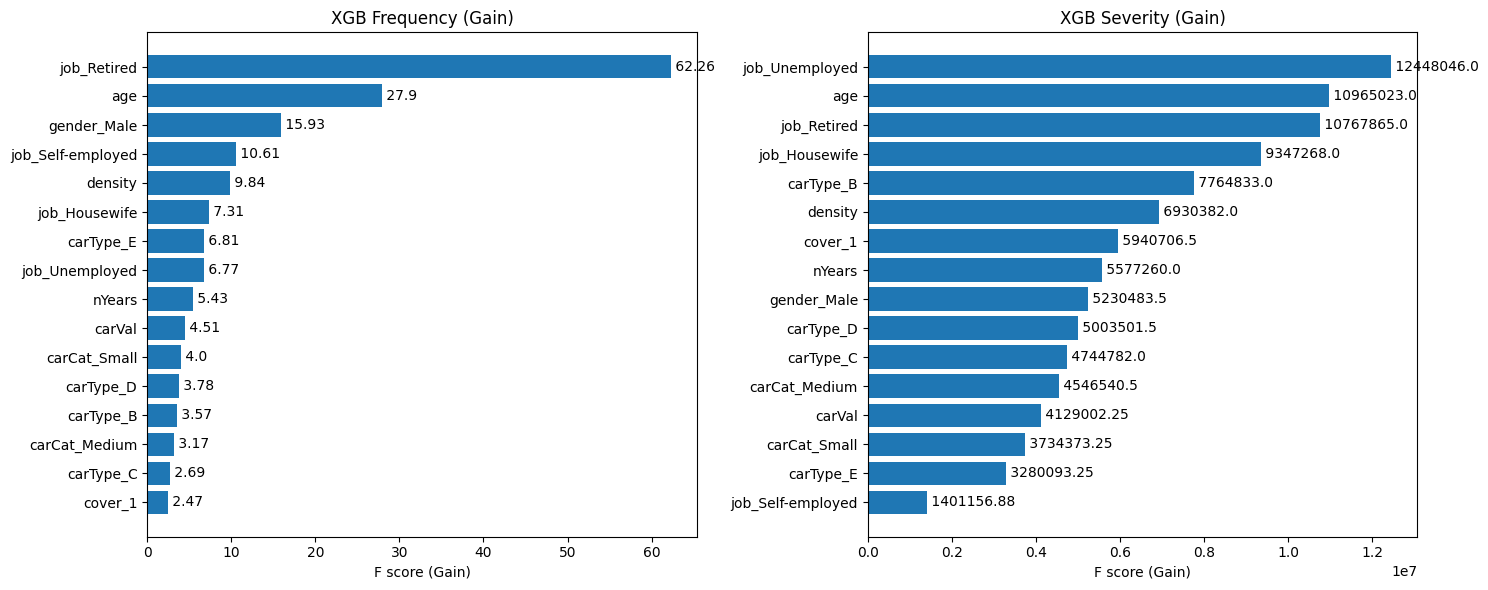

In [77]:
import matplotlib.pyplot as plt

importance_freq = xgb_class.get_booster().get_score(importance_type='gain')
importance_sev = xgb_reg.get_booster().get_score(importance_type='gain')

importance_freq_rounded = {k: round(v, 2) for k, v in importance_freq.items()}
importance_sev_rounded = {k: round(v, 2) for k, v in importance_sev.items()}

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

def plot_rounded_imp(rounded_dict, axis, title):
    # Sort by value
    sorted_dict = dict(sorted(rounded_dict.items(), key=lambda item: item[1]))
    axis.barh(list(sorted_dict.keys()), list(sorted_dict.values()))
    axis.set_title(title)
    axis.set_xlabel("F score (Gain)")
    # Add text labels
    for i, v in enumerate(sorted_dict.values()):
        axis.text(v, i, f" {v}", va='center')

plot_rounded_imp(importance_freq_rounded, ax[0], 'XGB Frequency (Gain)')
plot_rounded_imp(importance_sev_rounded, ax[1], 'XGB Severity (Gain)')

plt.tight_layout()
plt.show()

Frequency 
job_Retired -> either be safer drivers or have a very specific risk profile 
providing the most certainty to the model
age and gender_Male —younger male drivers are more risky
density is in the top 5-> where a person lives is more predictive of whether they will have an accident than the type of car they drive (carType)

Severity 
job_Unemployed is the top predictor for cost->possibly due to vehicle age or different usage patterns?
carType_B jumped much higher here than in Frequency->might not crash often, but when it does, repair costs are significantly higher 
Age/Density are important risk factors for preidcting both the accident and the cost

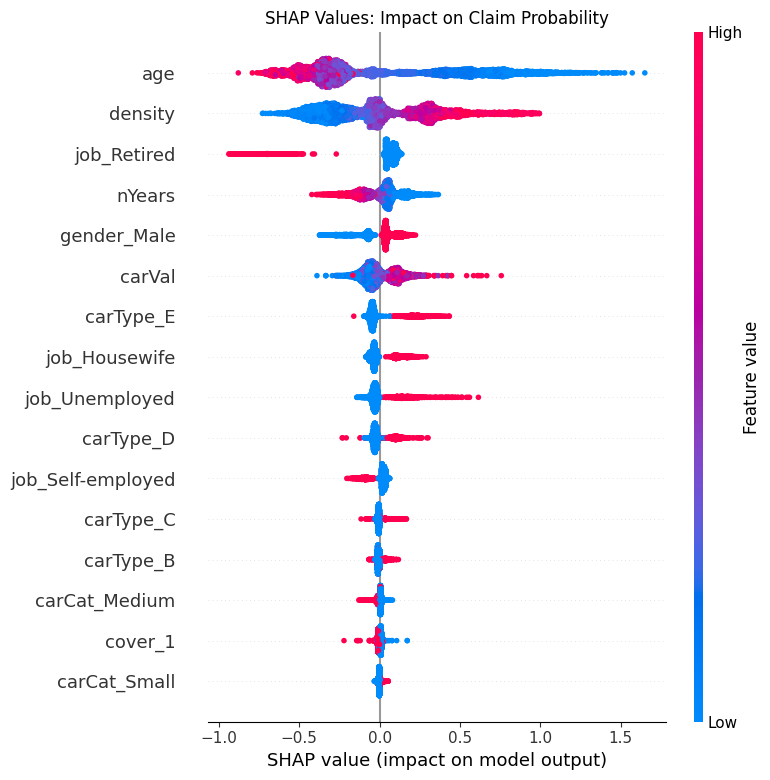

In [69]:
import shap

explainer = shap.TreeExplainer(xgb_class) 
shap_values = explainer.shap_values(X_test_f)

plt.title("SHAP Values: Impact on Claim Probability")
shap.summary_plot(shap_values, X_test_f)

Age - being young significantly increases the probability of a claim
red dots (older) are mostly on the left, decreasing risk
Density - red dots (High Density) areas increases claim probability, while rural areas (blue dots on the left) decrease it
job_Retired- long red bar on the far left shows that being retired has a downward pull  on claim probability -> safer
job_Unemployed - red dots spreading to the right-> increases the predicted risk, though the effect is smaller than the age or retirement 
gender_Male: red dots (Male) to the right -> higher probability of frequency 
carVal: High car values show a slight tail to the right -> higher risk

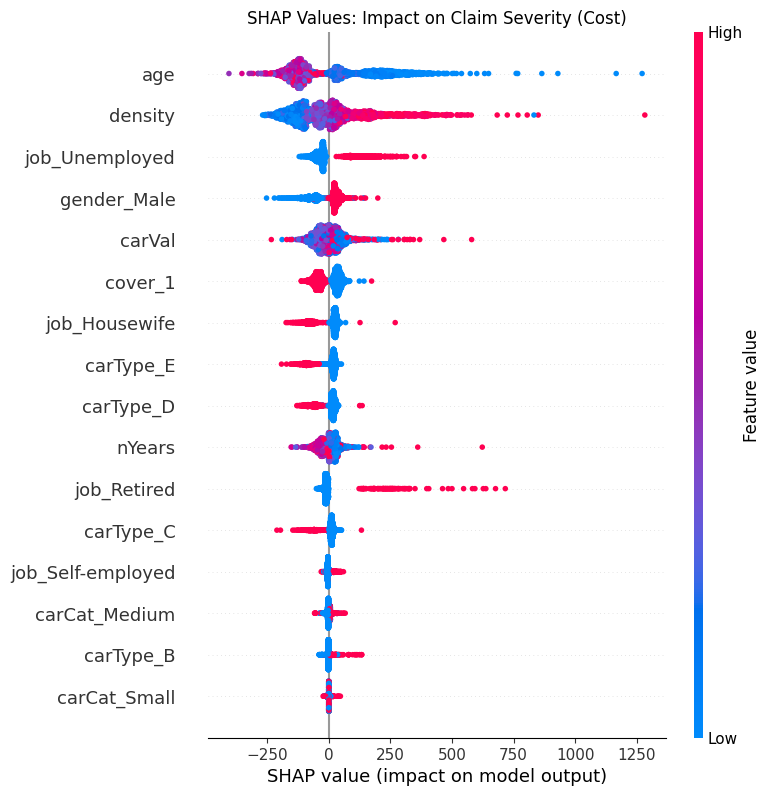

In [79]:
explainer_sev = shap.TreeExplainer(xgb_reg)
shap_values_sev = explainer_sev.shap_values(X_test_s)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_sev, X_test_s, show=False)
plt.title("SHAP Values: Impact on Claim Severity (Cost)")
plt.show()

blue dots (Younger Age) - right. when young people crash, the cost is significantly higher -high-impact claimants
Density - High-density areas cause more accidents, but low-density areas might involve higher speeds, leading to more severe damage 
job_Unemployed - associated with higher-than-average claim payouts.
job_Retired-while retirees crash infrequently, their claims results in higher costs
carVal (Car Value)-more expensive cars cost more to repair or replace
job_Housewife & carType_E/D-being a housewife or driving these specific car types appears to correlate with lower-cost claims 

Comparisons

In [89]:
comparison_df = test[['total_loss']].copy()

comparison_df['GLM_Hurdle'] = df_all["Expected_Cost"]
comparison_df['Tweedie_XGB'] = test['pred_m3'] 
comparison_df['XGB_Hurdle'] = df_test_results['pred_xgb_hurdle']

comparison_df = comparison_df.fillna(0)

In [90]:
comparison_df

,total_loss,GLM_Hurdle,Tweedie_XGB,XGB_Hurdle
5883,131.0,193.211742,119.394089,776.064392
9811,1262.0,159.730153,707.355530,392.817200
1888,1176.0,322.333908,603.332642,1004.224792
21278,701.0,54.089620,216.067795,302.726135
20316,1034.0,70.435500,400.892700,355.006897
...,...,...,...,...
17819,0.0,94.459097,581.394409,538.271118
18054,87.0,360.820204,63.666553,191.412064
6210,1779.0,507.358068,975.703430,307.957458
20451,0.0,740.480938,19.527346,147.962799


<Axes: title={'center': 'Actual Loss by Predicted Risk Decile'}, xlabel='decile'>

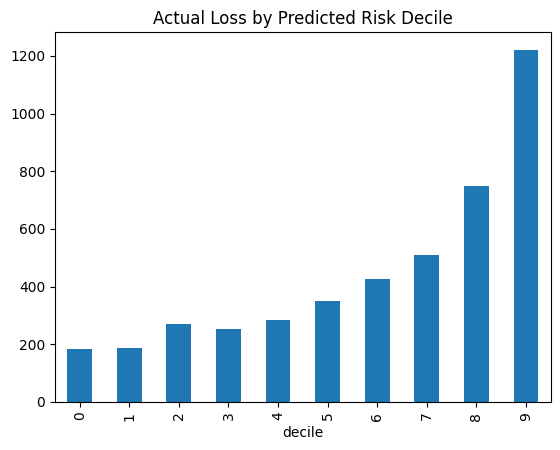

In [91]:
comparison_df['decile'] = pd.qcut(comparison_df['XGB_Hurdle'], 10, labels=False, duplicates='drop')
decile_analysis = comparison_df.groupby('decile')['total_loss'].mean()
decile_analysis.plot(kind='bar', title='Actual Loss by Predicted Risk Decile')

this is considering the total loss created as a proxy for tweedie as the actual cost
of course such a comparison will be biased towards the tweedie

In [99]:
test_indices = X_test_f.index

if 'claimOccur' not in df_all.columns:
    df_all['claimOccur'] = (df_all['claimNumbMD'] > 0).astype(int)

actual_occur_test = df_all.loc[test_indices, 'claimOccur']
glm_test_preds = df_all.loc[test_indices, 'Expected_Cost']

xgb_test_probs = xgb_test_probs_fixed = 1 - df_test_results['prob_claim']

from sklearn.metrics import roc_auc_score

auc_glm = roc_auc_score(actual_occur_test, glm_test_preds)
auc_xgb = roc_auc_score(actual_occur_test, xgb_test_probs)

print(f"Freq Model AUC Comparison:")
print(f"GLM: {auc_glm:.4f}")
print(f"XGB: {auc_xgb:.4f}")

Freq Model AUC Comparison:
GLM: 0.5056
XGB: 0.8369


In [98]:
sev_test_indices = X_test_s.index 

actual_sev_test = df_sev.loc[sev_test_indices, 'claimSizeMD']
glm_sev_preds = model_freq_v2.predict(df_sev.loc[sev_test_indices]) 

xgb_sev_preds = xgb_reg.predict(X_test_s)

from sklearn.metrics import mean_squared_error, mean_absolute_error

def print_metrics(actual, pred, label):
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mae = mean_absolute_error(actual, pred)
    print(f"{label} -> RMSE: {rmse:.2f}, MAE: {mae:.2f}")

print("Severity Model Comparison:")
print_metrics(actual_sev_test, glm_sev_preds, "GLM (Gamma)")
print_metrics(actual_sev_test, xgb_sev_preds, "XGB (Regressor)")

Severity Model Comparison:
GLM (Gamma) -> RMSE: 1346.23, MAE: 906.89
XGB (Regressor) -> RMSE: 957.27, MAE: 660.16


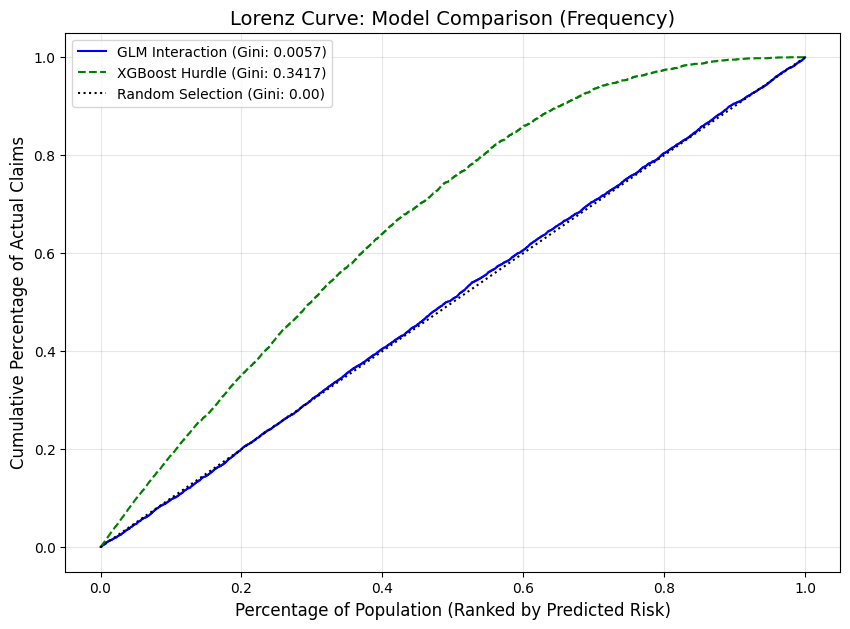

GLM Gini: 0.0057
XGB Gini: 0.3417


In [94]:
def get_gini_data(actual, predicted):
    df = pd.DataFrame({'actual': actual, 'pred': predicted}).sort_values('pred', ascending=False)
    df['cum_actual'] = df['actual'].cumsum() / df['actual'].sum()
    df['cum_pop'] = np.arange(1, len(df) + 1) / len(df)
    
    gini = 2 * (np.trapezoid(df['cum_actual'], df['cum_pop']) - 0.5)
    return df, gini

df_glm, gini_glm = get_gini_data(actual_occur_test, glm_test_preds)
df_xgb, gini_xgb = get_gini_data(actual_occur_test, xgb_test_probs)

plt.figure(figsize=(10, 7))
plt.plot(df_glm['cum_pop'], df_glm['cum_actual'], label=f'GLM Interaction (Gini: {gini_glm:.4f})', color='blue')
plt.plot(df_xgb['cum_pop'], df_xgb['cum_actual'], label=f'XGBoost Hurdle (Gini: {gini_xgb:.4f})', color='green', linestyle='--')
plt.plot([0, 1], [0, 1], 'k:', label='Random Selection (Gini: 0.00)')

plt.title('Lorenz Curve: Model Comparison (Frequency)', fontsize=14)
plt.xlabel('Percentage of Population (Ranked by Predicted Risk)', fontsize=12)
plt.ylabel('Cumulative Percentage of Actual Claims', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"GLM Gini: {gini_glm:.4f}")
print(f"XGB Gini: {gini_xgb:.4f}")

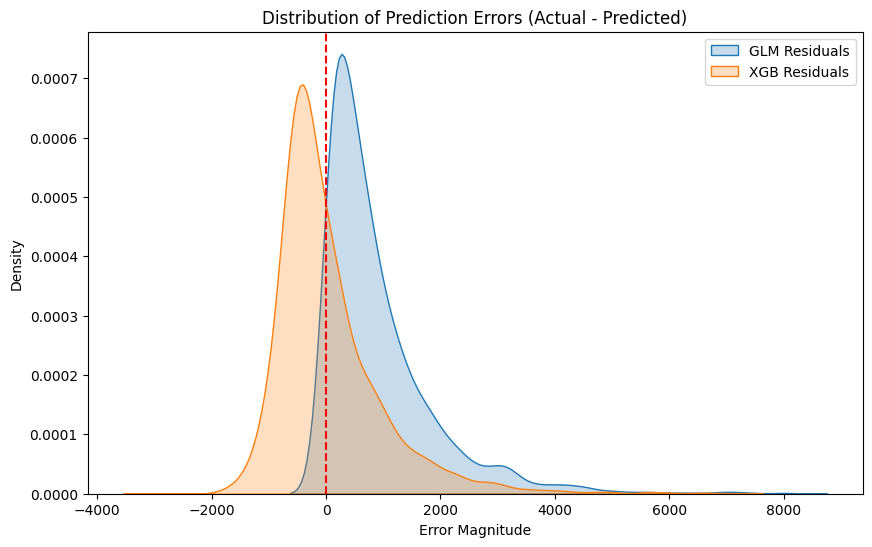

In [100]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.kdeplot(actual_sev_test - glm_sev_preds, label='GLM Residuals', fill=True)
sns.kdeplot(actual_sev_test - xgb_sev_preds, label='XGB Residuals', fill=True)
plt.axvline(0, color='red', linestyle='--')
plt.title('Distribution of Prediction Errors (Actual - Predicted)')
plt.xlabel('Error Magnitude')
plt.legend()
plt.show()

In [101]:
def get_severity_gini(actual, predicted):
    df = pd.DataFrame({'actual': actual, 'pred': predicted}).sort_values('pred', ascending=False)
    
    df['cum_actual'] = df['actual'].cumsum() / df['actual'].sum()
    df['cum_pop'] = np.arange(1, len(df) + 1) / len(df)
    
    gini = 2 * (np.trapezoid(df['cum_actual'], df['cum_pop']) - 0.5)
    return df, gini

df_gini_glm_s, gini_glm_s = get_severity_gini(actual_sev_test, glm_sev_preds)
df_gini_xgb_s, gini_xgb_s = get_severity_gini(actual_sev_test, xgb_sev_preds)

print(f"Severity Gini (Gamma GLM): {gini_glm_s:.4f}")
print(f"Severity Gini (XGB Regressor): {gini_xgb_s:.4f}")

Severity Gini (Gamma GLM): 0.0956
Severity Gini (XGB Regressor): 0.1705


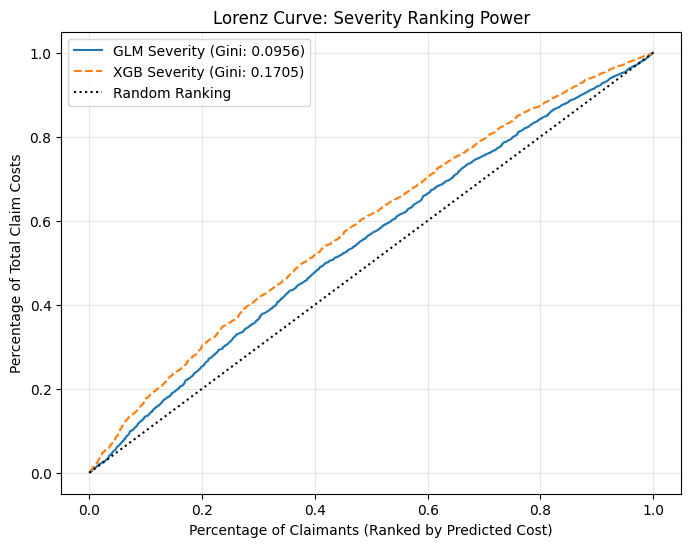

In [102]:
plt.figure(figsize=(8, 6))
plt.plot(df_gini_glm_s['cum_pop'], df_gini_glm_s['cum_actual'], label=f'GLM Severity (Gini: {gini_glm_s:.4f})')
plt.plot(df_gini_xgb_s['cum_pop'], df_gini_xgb_s['cum_actual'], label=f'XGB Severity (Gini: {gini_xgb_s:.4f})', linestyle='--')
plt.plot([0, 1], [0, 1], 'k:', label='Random Ranking')
plt.title('Lorenz Curve: Severity Ranking Power')
plt.xlabel('Percentage of Claimants (Ranked by Predicted Cost)')
plt.ylabel('Percentage of Total Claim Costs')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [92]:
print("Avg predicted prob for Non-Claimants:", xgb_test_probs[actual_occur_test == 0].mean())
print("Avg predicted prob for Claimants:", xgb_test_probs[actual_occur_test == 1].mean())

Avg predicted prob for Non-Claimants: 0.5954758
Avg predicted prob for Claimants: 0.39280054


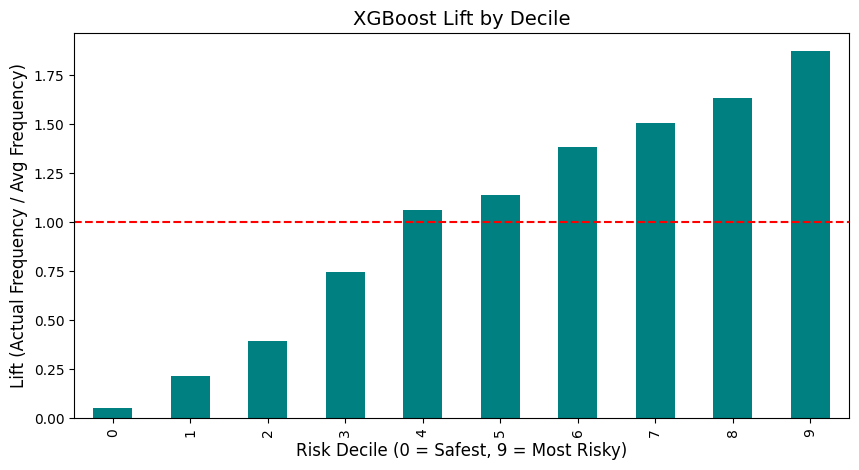

In [95]:
comparison_df = pd.DataFrame({'actual': actual_occur_test, 'xgb_p': xgb_test_probs, 'glm_p': glm_test_preds})
comparison_df['decile'] = pd.qcut(comparison_df['xgb_p'], 10, labels=False)

# Calculate lift per decile
lift_table = comparison_df.groupby('decile')['actual'].mean() / comparison_df['actual'].mean()

# Visualizing Lift
lift_table.plot(kind='bar', color='teal', figsize=(10, 5))
plt.axhline(1, color='red', linestyle='--')
plt.title('XGBoost Lift by Decile', fontsize=14)
plt.xlabel('Risk Decile (0 = Safest, 9 = Most Risky)', fontsize=12)
plt.ylabel('Lift (Actual Frequency / Avg Frequency)', fontsize=12)
plt.show()

the first 20% of the x-axis (% of pop) -> green line shoots up to nearly 40%
if the insurance company only insured the 20% of people the XGBoost model flagged as most risky they would have captured  40% of all claims
demonstrates that the non-linear interactions captured by XGBoost are superior to the parametric GLM

AUC of 0.5056 means the GLM is basically a coin flip
